In [4]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode

import scipy.io as sio
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

In [5]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [6]:
data = sio.loadmat('/home/bonaiuto/visual_laminar/results/stats_VBA/ERF_OverTime_Contra_family.mat') # VBA results Contra
bestModelOverTime = data['bestModelOverTime'].squeeze()
time = data['time'].squeeze()

delta = np.load('/home/bonaiuto/visual_laminar/results/stats_VBA/ERF_means.npz') #deltaF + ts ERF

Contra_la_mean = delta['Contra_la_mean']
Ipsi_la_mean   = delta['Ipsi_la_mean']
Contra_ts_mean = delta['Contra_ts_mean']
Ipsi_ts_mean   = delta['Ipsi_ts_mean']
woi_win =   delta['woi_win']
ts_time =  delta['ts_time']


In [7]:
time_lims=[-300,300]
woi_time=woi_win
t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
woi_win=woi_time[t_idx]

col_l = plt.cm.cool(np.linspace(0, 1, num=6))
layer_colors = col_l

color_model_1 = layer_colors[0:3].mean(axis=0)
color_model_2 = layer_colors[3]
color_model_3 = layer_colors[4:6].mean(axis=0)

model_colors = {
    1: color_model_1,
    2: color_model_2,
    3: color_model_3
}

mask_woi = (ts_time >= woi_win[0]) & (ts_time <= woi_win[-1])

time_woi = ts_time[mask_woi]
model_woi_c = bestModelOverTime[mask_woi]

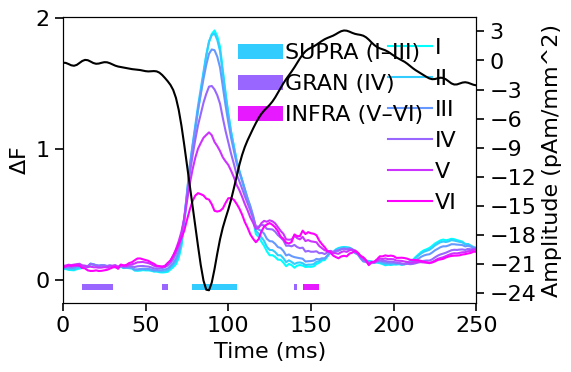

In [13]:
# Contra 
model_woi = model_woi_c

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)

l_labels = ['I', 'II', 'III', 'IV', 'V', 'VI']

for i in range(6):
    ax.plot(
        woi_win,
        Contra_la_mean[i, :],
        label=l_labels[i],
        color=col_l[i]
    )

#ax.axvline(x=0, color='k', linestyle='--')

leg_layers = ax.legend(loc='upper right', frameon=False)
ax.add_artist(leg_layers)


y_model = -0.05
start_idx = 0

for i in range(1, len(model_woi) + 1):
    if i == len(model_woi) or model_woi[i] != model_woi[start_idx]:
        model = model_woi[start_idx]
        if model != 0:
            t_start = time_woi[start_idx]
            t_end = time_woi[i - 1]
            ax.barh(
                y_model,
                width=t_end - t_start + np.median(np.diff(time_woi)),
                left=t_start,
                color=model_colors[model],
                height=0.05
            )
        start_idx = i


model_handles = [
    Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I–III)'),
    Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
    Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V–VI)')
]

ax.legend(
    handles=model_handles,
    loc='upper right',
    bbox_to_anchor=(0.92, 0.98),
    frameon=False
)


ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


ax2 = ax.twinx()
ax2.plot(ts_time, Contra_ts_mean*1000, 'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim([0, 250])
plt.tight_layout()

plt.savefig('./figure_08_visual_erf_contralateral_aligned.pdf')

In [14]:
data = sio.loadmat('/home/bonaiuto/visual_laminar/results/stats_VBA/ERF_OverTime_Ipsi_family.mat') # VBA results Ipsi
bestModelOverTime = data['bestModelOverTime'].squeeze()
time = data['time'].squeeze()

delta = np.load('/home/bonaiuto/visual_laminar/results/stats_VBA/ERF_means.npz') #deltaF + ts ERF

Contra_la_mean = delta['Contra_la_mean']
Ipsi_la_mean   = delta['Ipsi_la_mean']
Contra_ts_mean = delta['Contra_ts_mean']
Ipsi_ts_mean   = delta['Ipsi_ts_mean']
woi_win =   delta['woi_win']
ts_time =  delta['ts_time']


In [15]:
time_lims=[-300,300]
woi_time=woi_win
t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
woi_win=woi_time[t_idx]

col_l = plt.cm.cool(np.linspace(0, 1, num=6))
layer_colors = col_l

color_model_1 = layer_colors[0:3].mean(axis=0)
color_model_2 = layer_colors[3]
color_model_3 = layer_colors[4:6].mean(axis=0)

model_colors = {
    1: color_model_1,
    2: color_model_2,
    3: color_model_3
}

mask_woi = (ts_time >= woi_win[0]) & (ts_time <= woi_win[-1])

time_woi = ts_time[mask_woi]
model_woi_c = bestModelOverTime[mask_woi]

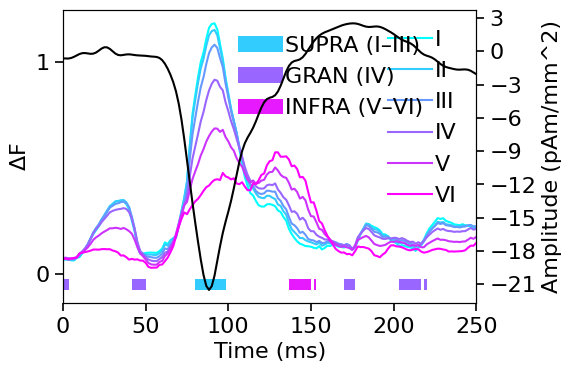

In [20]:
# Ipsi
model_woi = model_woi_c

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)

l_labels = ['I', 'II', 'III', 'IV', 'V', 'VI']

for i in range(6):
    ax.plot(
        woi_win,
        Ipsi_la_mean[i, :],
        label=l_labels[i],
        color=col_l[i]
    )

#ax.axvline(x=0, color='k', linestyle='--')

leg_layers = ax.legend(loc='upper right', frameon=False)
ax.add_artist(leg_layers)


y_model = -0.05
start_idx = 0

for i in range(1, len(model_woi) + 1):
    if i == len(model_woi) or model_woi[i] != model_woi[start_idx]:
        model = model_woi[start_idx]
        if model != 0:
            t_start = time_woi[start_idx]
            t_end = time_woi[i - 1]
            ax.barh(
                y_model,
                width=t_end - t_start + np.median(np.diff(time_woi)),
                left=t_start,
                color=model_colors[model],
                height=0.05
            )
        start_idx = i


model_handles = [
    Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I–III)'),
    Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
    Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V–VI)')
]

ax.legend(
    handles=model_handles,
    loc='upper right',
    bbox_to_anchor=(0.92, 0.98),
    frameon=False
)


ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = ax.twinx()
ax2.plot(ts_time, Ipsi_ts_mean*1000, 'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim([0, 250])
plt.tight_layout()
plt.savefig('./figure_SX_visual_erf_ipsilateral_aligned.pdf')